In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter


In [2]:
df = pd.read_csv('../data/FINAL_DATA.csv')

df['Clean_Reviews'] = df['Clean_Reviews'].astype(str).str.strip()
df['Sentiment_label'] = df['Sentiment_label'].astype(int)

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print('Dataset loaded:', df.shape)
print(df['Sentiment_label'].value_counts())

Dataset loaded: (20913, 2)
Sentiment_label
2    12539
0     5345
1     3029
Name: count, dtype: int64


In [3]:
test_df = pd.read_csv("../results/transformer_test_set.csv")

print(f"Test set size: {len(test_df)}")
print(test_df['true_label'].value_counts())

Test set size: 3137
true_label
2    1881
0     802
1     454
Name: count, dtype: int64


In [ ]:
#Evaluation of a transformer model

#  Load transformer predictions 
with open("../results/transformer_results.json") as f:
    data = json.load(f) #loads the logits and labels

model_name = "MuRIL"
res = data[model_name]  

logits = np.array(res[0])

#  Convert logits → predictions 
preds = np.argmax(logits, axis=1)

#align safely  - so no mismatch b/w preds and datset size
min_len = min(len(test_df), len(preds))

test_df = test_df.iloc[:min_len].copy()
test_df["predicted"] = preds[:min_len]

# Error analysis 
errors = test_df[test_df["true_label"] != test_df["predicted"]].copy() #filters only wrong prediction

print(f"Model name: {model_name}")
print(f"Total test  : {len(test_df)}")
print(f"Total errors: {len(errors)}")
print(f"Error rate  : {len(errors)/len(test_df):.2%}")

Model name: MuRIL
Total test  : 3137
Total errors: 462
Error rate  : 14.73%


In [ ]:
# Error categorisation analysis

negation_words  = ['nahi','nhi','na','mat','nay','nae','never','not',
                   'no','nope','bilkul nhi','bilkul nahi']
sarcasm_markers = ['wah','zabardast','kya baat','bilkul','amazing',
                   'perfect','great','wonderful','lol','haha','very nice',
                   'mashallah','subhanallah']
slang_words     = ['yaar','bhai','uff','arey','arrey','omg','wtf',
                   'yr','bc','mamu','pagal','bakwaas','bekar']
mixed_markers   = ['but','lekin','magar','par ','phir bhi','however',
                   'although','acha hai magar','acha but']

def categorize(text): #for each wrong prediction
    t = str(text).lower()
    cats = []
    if any(w in t for w in negation_words):  cats.append('Negation handling')
    if any(w in t for w in sarcasm_markers): cats.append('Sarcasm / irony')
    if any(w in t for w in slang_words):     cats.append('Slang / informal')
    if any(w in t for w in mixed_markers):   cats.append('Mixed sentiment')
    if not cats:                              cats.append('Other / ambiguous')
    return cats

errors['error_types'] = errors['Text'].apply(categorize)

all_types  = [t for types in errors['error_types'] for t in types] 
#Because each sentence can have multiple categories, you flatten them into one list.

type_counts = Counter(all_types)
#This counts how many errors belong to each category.

print('Error type breakdown:')
for t, c in type_counts.most_common():
    print(f'  {t:30s}: {c:4d}  ({c/len(errors):.1%})')

Error type breakdown:
  Negation handling             :  240  (51.9%)
  Mixed sentiment               :  168  (36.4%)
  Other / ambiguous             :  146  (31.6%)
  Slang / informal              :   46  (10.0%)
  Sarcasm / irony               :   31  (6.7%)


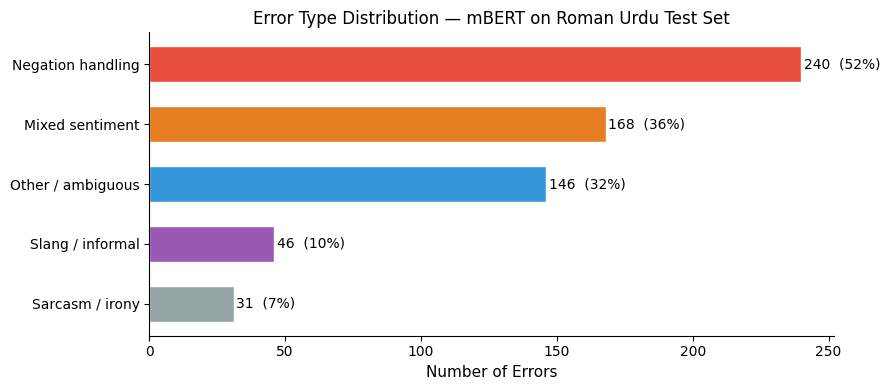

Saved: results/Images/error_type_distribution.png


In [ ]:
# Plot 1: Error type distribution bar chart 

fig, ax = plt.subplots(figsize=(9, 4))

types, counts = zip(*type_counts.most_common())
colors = ['#e74c3c','#e67e22','#3498db','#9b59b6','#95a5a6']

bars = ax.barh(list(types), list(counts),
               color=colors[:len(types)], edgecolor='white', height=0.6)

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{count}  ({count/len(errors):.0%})',
            va='center', fontsize=10)

ax.set_xlabel('Number of Errors', fontsize=11)
ax.set_title('Error Type Distribution — mBERT on Roman Urdu Test Set', fontsize=12)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/Images/error_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/Images/error_type_distribution.png')

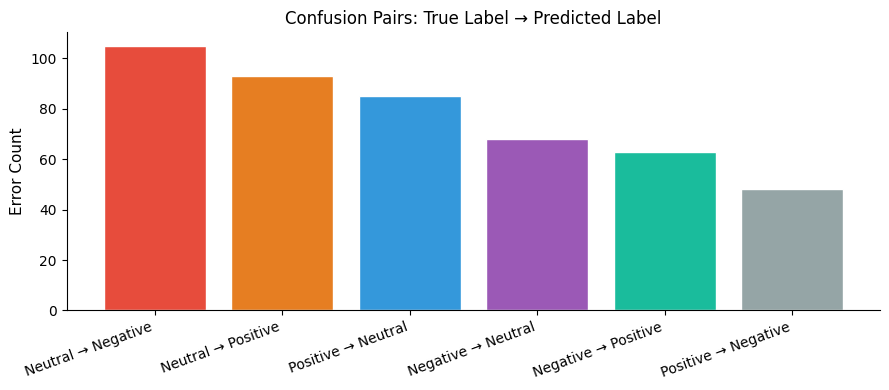

Saved: results/confusion_pairs.png


In [ ]:
# Plot 2: Confusion pairs — which class gets confused with which

confusion_data = {}
for true in [0, 1, 2]:
    for pred in [0, 1, 2]:
        if true != pred:
            key = f'{label_names[true]} → {label_names[pred]}'
            confusion_data[key] = len(errors[
                (errors['true_label'] == true) &
                (errors['predicted']  == pred)
            ])

sorted_conf = dict(sorted(confusion_data.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#e74c3c','#e67e22','#3498db','#9b59b6','#1abc9c','#95a5a6']
ax.bar(list(sorted_conf.keys()), list(sorted_conf.values()),
       color=bar_colors, edgecolor='white')
ax.set_ylabel('Error Count', fontsize=11)
ax.set_title('Confusion Pairs: True Label → Predicted Label', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../results/Images/confusion_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/confusion_pairs.png')

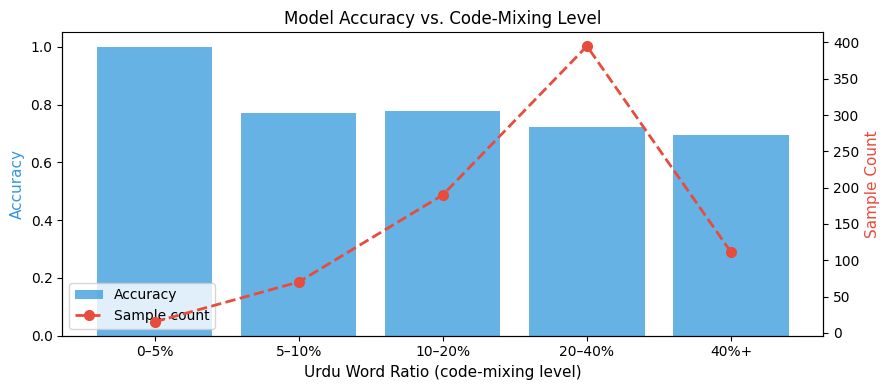

Saved: results/accuracy_vs_mixing.png

Accuracy per bucket:
bucket
0–5%      1.000
5–10%     0.771
10–20%    0.779
20–40%    0.724
40%+      0.694
Name: correct, dtype: float64

Sample counts:
bucket
0–5%       15
5–10%      70
10–20%    190
20–40%    395
40%+      111
Name: correct, dtype: int64


In [ ]:
#Plot 3: Accuracy vs code-mixing level 
# My Research insight: does accuracy drop as Urdu ratio increases?

urdu_words = [
    'hai','ka','ki','ke','mein','se','ko','nahi','aur','yeh',
    'kya','hum','tum','tha','thi','hy','nhi','bhi','jo','ye',
    'wo','ap','hain','koi','bahut','bohat','yaar','bhai'
]

def mixing_ratio(text): # FRACTION OF URDU WORDS IN OUR SENTENCES
    words = str(text).lower().split()
    if not words:
        return 0
    return sum(1 for w in words if w in urdu_words) / len(words)

test_df['urdu_ratio'] = test_df['Text'].apply(mixing_ratio)

"""
 FROM THE ABOVE CODE LINE, now each sentence has a value urdu ratio like (0.2-> low urdu, 0.8->high urdu)
"""

test_df['correct']    = (test_df['true_label'] == test_df['predicted']).astype(int)

test_df['bucket'] = pd.cut( # group the buckets (0-5% -> highly english, 40%+ -> highly urdu)
    test_df['urdu_ratio'],
    bins=[0, 0.05, 0.10, 0.20, 0.40, 1.01],
    labels=['0–5%', '5–10%', '10–20%', '20–40%', '40%+']
)

acc_by_bucket   = test_df.groupby('bucket', observed=True)['correct'].mean()
count_by_bucket = test_df.groupby('bucket', observed=True)['correct'].count()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(acc_by_bucket.index, acc_by_bucket.values,           # show performance per bucket
        color='#3498db', alpha=0.75, label='Accuracy')
ax2.plot(acc_by_bucket.index, count_by_bucket.values,           # sows how may snetences exist in each bucket
         'o--', color='#e74c3c', linewidth=2, markersize=7, label='Sample count')

ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Accuracy', color='#3498db', fontsize=11)
ax2.set_ylabel('Sample Count', color='#e74c3c', fontsize=11)
ax1.set_xlabel('Urdu Word Ratio (code-mixing level)', fontsize=11)
ax1.set_title('Model Accuracy vs. Code-Mixing Level', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

ax1.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/Images/accuracy_vs_mixing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/accuracy_vs_mixing.png')
print('\nAccuracy per bucket:')
print(acc_by_bucket.round(3))
print('\nSample counts:')
print(count_by_bucket)

In [ ]:
#Real error examples - qualitative error analysis
""""
this code will pritn actual misclassified sentences for each error category
explaining why model fails in real cases
"""
print('=' * 68)
print('REAL ERROR EXAMPLES ')
print('=' * 68)

categories_to_show = [  # cateogory name + explanation 
    ('Negation handling', 'Model misses Urdu negation words like nahi / nhi'),
    ('Sarcasm / irony',   'Model takes positive words literally'),
    ('Slang / informal',  'Pakistani slang not in model vocabulary'),
    ('Mixed sentiment',   'Sentence has both positive and negative parts'),
]

for cat, explanation in categories_to_show:
    subset = errors[
        errors['error_types'].apply(lambda x: cat in x)  #keep rows where curretn category appears (only first 3)
    ].head(3)

    print(f'\n--- {cat} ---')
    print(f'    Why: {explanation}')

    if len(subset) == 0:
        print('    (No examples found — your dataset may use different spellings)')
        continue

    for _, row in subset.iterrows():
        tl = label_names[int(row['true_label'])]
        pl = label_names[int(row['predicted'])]
        print(f'    Text      : {str(row["Text"])[:75]}')
        print(f'    True label: {tl:10s}  |  Predicted: {pl}')
        print()

REAL ERROR EXAMPLES 

--- Negation handling ---
    Why: Model misses Urdu negation words like nahi / nhi
    Text      : subse acha true wireless asal masnoaat
    True label: Neutral     |  Predicted: Positive

    Text      : my amount was rs and they charged rupees extra for what could u please let 
    True label: Neutral     |  Predicted: Negative

    Text      : i dikhai bhji i not fear
    True label: Negative    |  Predicted: Positive


--- Sarcasm / irony ---
    Why: Model takes positive words literally
    Text      : gandi watch he bilkul nakul dedi he ap jese sellar daraz ko badnam karte he
    True label: Negative    |  Predicted: Positive

    Text      : yeh iss ke kaam karne ki terhan kaam karta hai tamam tareeqon se bilkul kaa
    True label: Negative    |  Predicted: Neutral

    Text      : kind of small than what i assumed but good quality and perfect for kids lov
    True label: Positive    |  Predicted: Neutral


--- Slang / informal ---
    Why: Pakistani slan

In [ ]:
#  Save all error analysis outputs 

summary = {
    'total_test_samples' : int(len(test_df)),
    'total_errors'       : int(len(errors)),
    'error_rate'         : round(float(len(errors)) / len(test_df), 4),
    'error_types'        : {k: int(v) for k, v in type_counts.most_common()},
    'confusion_pairs'    : {k: int(v) for k, v in sorted_conf.items()},
    'accuracy_by_mixing_bucket': {
        str(k): round(float(v), 4)
        for k, v in acc_by_bucket.items()
    }
}

with open('../results/error_analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

errors[['Text', 'true_label', 'predicted', 'error_types']].head(100).to_csv(
    '../results/error_examples.csv', index=False
)

print('All error analysis outputs saved!')
print()
print('Files created:')
print('  results/Images/error_type_distribution.png')
print('  results/Images/confusion_pairs.png')
print('  results/Images/accuracy_vs_mixing.png')
print('  results/Images/error_analysis_summary.json')
print('  results/Images/error_examples.csv')

All error analysis outputs saved!

Files created:
  results/Images/error_type_distribution.png
  results/Images/confusion_pairs.png
  results/Images/accuracy_vs_mixing.png
  results/Images/error_analysis_summary.json
  results/Images/error_examples.csv
